# 04 — Probe resolution degradation

**Question:** how does reducing probe-crop resolution change verification performance?

Conditions: the exact original 160 × 160 crop, and crops reduced to 80 × 80, 40 × 40, or 20 × 20 before being enlarged to 160 × 160 for the model.

Use the working Commit 5 Python environment and retain its local baseline cache. The reference embeddings, crop selection, model, baseline thresholds, and baseline eligible pairs remain fixed. No detection, threshold calibration, or model training is performed on degraded images.

Measured outputs and observations from the completed run are saved below.


In [1]:
from pathlib import Path
import sys
import json

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src/resolution_experiment.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open Jupyter inside Evaluating-Face-Verification.')
sys.path.insert(0, str(ROOT / 'src'))
from resolution_experiment import run_resolution
print('Python:', sys.version)
print('Interpreter:', sys.executable)


Python: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
Interpreter: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification/.venv/bin/python


## 1. Run the four conditions
The 160-pixel condition reproduces cached baseline scores and metrics. One original probe is also passed through the current model again to check numerical compatibility.

For reduced resolutions, Pillow BOX performs area averaging when shrinking, and BILINEAR enlarges back to the model input size. Float32 channels avoid introducing an additional uint8 quantization step. Standardization is applied once by the unchanged embedding helper after degradation.

The experiment checks baseline export hashes, cache fingerprints and payload hashes, and model/environment consistency. It scores exactly the same eligible pairs at every level. An invalid degraded embedding stops the experiment rather than silently removing a pair.

Progress prints every 100 unique probes. Completed degraded embeddings are cached independently. After interruption, rerun this cell. Keep only one experiment process running against a cache at a time.


In [2]:
report = run_resolution(ROOT)
if report['status'] != 'completed':
    raise RuntimeError('Resolution experiment did not complete.')
print('Resolution | Scored pairs | Accuracy | FMR | FNMR | Accuracy change (pp)')
for row in report['conditions']:
    print(f"{row['resolution']:>7}px | {row['scored_pairs']:>5}/{row['requested_pairs']} | "
          f"{100*row['mean_accuracy']:.3f}% | {100*row['mean_fmr']:.3f}% | "
          f"{100*row['mean_fnmr']:.3f}% | {row['delta_accuracy_pp']:+.3f}")
print(f"Elapsed time: {report['elapsed_seconds']/60:.2f} minutes")


Verifying baseline results and cached crops ...


160px: accuracy 99.167%, FMR 0.433%, FNMR 1.234%


80px: 100/4575 probes | reused 0


80px: 200/4575 probes | reused 0


80px: 300/4575 probes | reused 0


...

20px: 4400/4575 probes | reused 0


20px: 4500/4575 probes | reused 0


20px: 4575/4575 probes | reused 0


20px: accuracy 89.982%, FMR 0.967%, FNMR 19.071%


Resolution | Scored pairs | Accuracy | FMR | FNMR | Accuracy change (pp)
    160px |  5999/6000 | 99.167% | 0.433% | 1.234% | +0.000
     80px |  5999/6000 | 99.117% | 0.433% | 1.334% | -0.050
     40px |  5999/6000 | 98.833% | 0.467% | 1.867% | -0.333
     20px |  5999/6000 | 89.982% | 0.967% | 19.071% | -9.185
Elapsed time: 3.42 minutes


## 2. See what resolution reduction changes
The example below uses one baseline-eligible probe. It is illustrative, not a representative random sample. Each panel is displayed at the same dimensions, but lower-resolution panels contain less spatial detail.


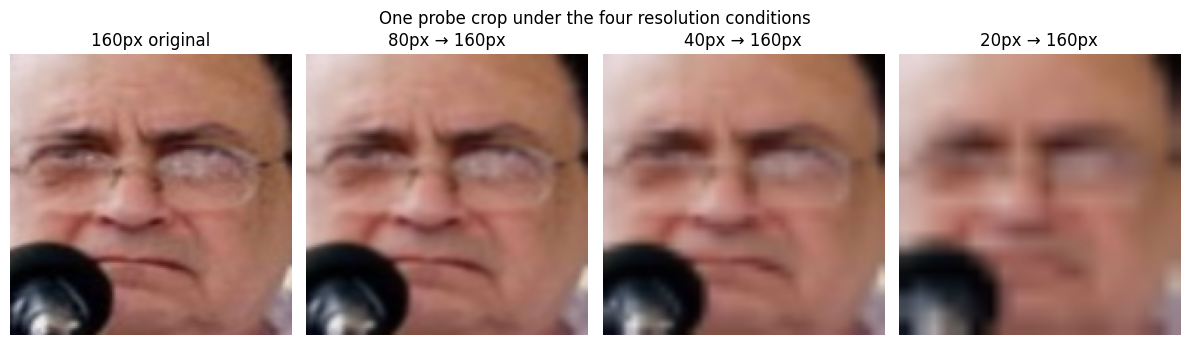

In [3]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from degradation import RESOLUTIONS, reduce_resolution

with (ROOT / 'results/metrics/baseline_scores.csv').open(newline='', encoding='utf-8') as stream:
    example = next(row for row in csv.DictReader(stream) if row['status'] == 'scored')
cache = ROOT / report['baseline_cache']
manifest = json.loads((cache / 'manifest.json').read_text())
record = manifest['images'][example['probe']]
with np.load(cache / record['payload'], allow_pickle=False) as data:
    original = data['crop'].copy()
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, size in zip(axes, RESOLUTIONS):
    crop = reduce_resolution(original, size)
    ax.imshow(np.clip(crop.transpose(1, 2, 0), 0, 255).astype(np.uint8))
    ax.set_title('160px original' if size == 160 else f'{size}px → 160px')
    ax.axis('off')
fig.suptitle('One probe crop under the four resolution conditions')
fig.tight_layout()
plt.show()


## 3. Compare accuracy and error rates
All values use saved original-condition thresholds and the same baseline eligible pairs. These are conditional recognition metrics: the baseline preprocessing failure remains excluded at every level and is still listed in the prediction exports.

Changes are measured in percentage points relative to 160 pixels. A negative accuracy change means lower accuracy. Positive FMR/FNMR changes mean increased error rates. Rates need not change monotonically on every finite sample.


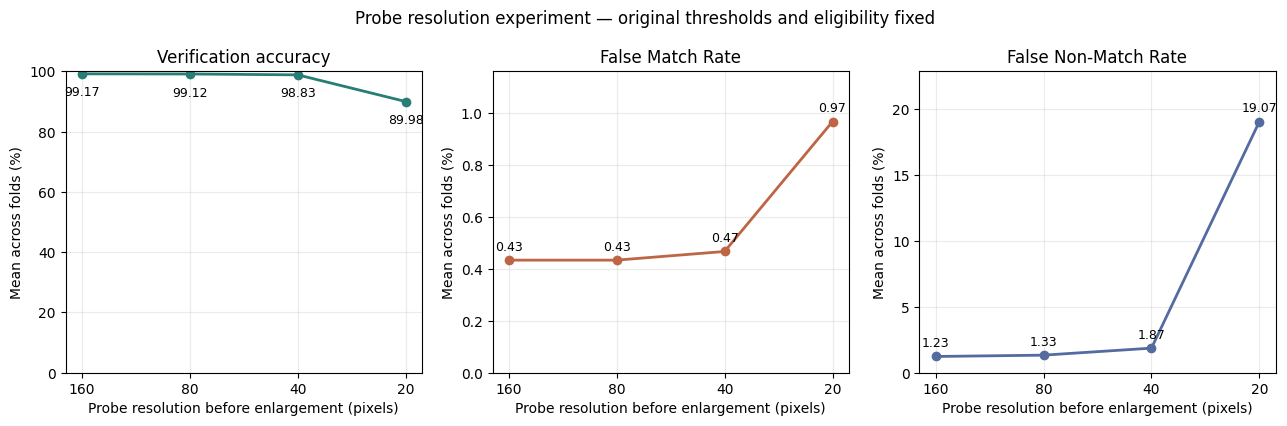

In [2]:
conditions = report['conditions']
x = np.arange(len(conditions))
labels = [str(row['resolution']) for row in conditions]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, metric, title, color in zip(axes, ['accuracy', 'fmr', 'fnmr'],
                                  ['Verification accuracy', 'False Match Rate', 'False Non-Match Rate'],
                                  ['#277e76', '#bd6544', '#536b9f']):
    y = [100*row[f'mean_{metric}'] for row in conditions]
    ax.plot(x, y, marker='o', color=color, linewidth=2)
    ax.set_xticks(x, labels)
    ax.set_xlabel('Probe resolution before enlargement (pixels)')
    ax.set_ylabel('Mean across folds (%)')
    ax.set_title(title)
    ax.grid(alpha=.25)
    for position, value in zip(x,y):
        offset = -16 if metric == 'accuracy' else 7
        ax.annotate(f'{value:.2f}', (position,value), xytext=(0,offset), textcoords='offset points', ha='center', fontsize=9)
    if metric == 'accuracy':
        ax.set_ylim(0,100)
    else:
        ax.set_ylim(0,max(1,max(y)*1.2))
fig.suptitle('Probe resolution experiment — original thresholds and eligibility fixed')
fig.tight_layout()
figure_dir = ROOT / 'results/figures'
figure_dir.mkdir(parents=True,exist_ok=True)
fig.savefig(figure_dir / 'resolution_comparison.png', dpi=160)
plt.show()


## 4. Your observations

The experiment started on 2026-09-11 at 11:14:43 EDT, using the same
Python 3.13.7 CPU environment and frozen model as the baseline. All four
conditions finished in 205.242 seconds (3.42 minutes). Each reduced condition
processed 4,575 unique probes, producing 13,725 fresh degraded embeddings in total.
The 160px control reused baseline embeddings; its additional real forward check
had maximum absolute difference 0.0 from the cached vector.

The 160px condition exactly reproduced the baseline: 99.167% mean fold accuracy,
0.433% FMR, 1.234% FNMR, 13 false matches, and 37 false non-matches. All four
conditions retained the same 5,999 eligible pairs out of 6,000 (99.983% coverage),
with the same genuine pair excluded in fold 2. There were no additional exclusions.
All reference embeddings and saved fold thresholds stayed fixed.

At 80px, accuracy was 99.117%, a decrease of 0.050 percentage points. FMR remained
0.433%, while FNMR rose to 1.334%; error counts were 13 false matches and 40 false
non-matches. At 40px, accuracy was 98.833%, down 0.333 percentage points, with
0.467% FMR and 1.867% FNMR (14 false matches and 56 false non-matches).

The strongest tested reduction, 20px, had the largest accuracy decrease:
9.185 percentage points, to 89.982%. FMR rose by 0.533 percentage points to 0.967%,
and FNMR rose by 17.838 percentage points to 19.071%. This condition had 29 false
matches and 572 false non-matches. The main deterioration at the fixed operating
thresholds was rejection of genuine comparisons. These are descriptive results;
no significance test was performed and the means do not prove a general cutoff.

Visual inspection of the notebook's example crops showed progressively softer
edges and less detail around the glasses, eyes, and mouth, especially at 20px.
Enlargement restored the input dimensions without restoring that visible detail.
The displayed probe is one illustrative example, not a representative sample.
The comparison chart was reviewed; accuracy labels were moved below the points
to avoid touching the upper axis border. Only the plot cell was re-executed from
the saved metrics, so inference results and metric reports were unchanged.

All 5 resolution tests and all 16 earlier regression tests passed. The supplied
synthetic integration test checked cache reuse, baseline immutability, and
rejection of corrupt baseline payloads. Independent checks verified all 24,000
prediction rows, all 40 fold results, all 13,725 cached degraded embeddings and
receipts, fixed thresholds and eligibility, and the aggregate means, SD/SE,
error counts, and percentage-point changes. Nine additional real-probe checks
used independent block averaging before enlargement and reproduced cached
embeddings within 1e-6. Baseline report, manifest, and original payload hashes
were unchanged. All five notebook code cells completed without execution errors.

No dependency changes, installation fixes, or model/preprocessing changes were
needed. The existing LF CSV writer preserved the recorded output hashes.
Instructions remain in README.md; model/environment and source fingerprints
are in the result JSON. The result measures synthetic loss of spatial detail
after cropping. It does not evaluate detection on degraded photographs or all
camera artifacts; training-data overlap with LFW remains independently unaudited.


## 5. Generate the experiment-log entry
Copy the printed draft into `docs/experiment_log.md` and replace the observations placeholder. Save this notebook with outputs and your observations before committing.


In [5]:
lines = [
    '## Stage 006 — Probe Resolution Degradation',
    '', '### Run (UTC)', report['run_at_utc'], '',
    '### Method',
    'Reduced probe crops to 80, 40, and 20 pixels with BOX downsampling,',
    'then enlarged to 160 pixels using BILINEAR interpolation. Retained',
    'float32 pixels and applied the existing normalization once afterward.',
    'Kept reference embeddings, original face crops, the model, baseline',
    'eligible pairs, and baseline fold thresholds fixed.',
    '', '### Measured Results',
    '| Probe pixels | Scored pairs | Accuracy | FMR | FNMR | Accuracy change (pp) |',
    '|---:|---:|---:|---:|---:|---:|',
]
for row in report['conditions']:
    lines.append(f"| {row['resolution']} | {row['scored_pairs']} | {100*row['mean_accuracy']:.3f}% | "
                 f"{100*row['mean_fmr']:.3f}% | {100*row['mean_fnmr']:.3f}% | {row['delta_accuracy_pp']:+.3f} |")
lines += ['', '### Observations and Problems', '[Add your actual observations and fixes.]', '',
          '### Limitations', 'The same baseline exclusions apply at every level. This experiment measures',
          'synthetic resolution loss after face cropping, not degraded-image detection.',
          'Training-data overlap remains independently unaudited.', '',
          '### Next Step', 'Apply Gaussian blur to probe crops using the same baseline comparison protocol.']
print(chr(10).join(lines))


## Stage 006 — Probe Resolution Degradation

### Run (UTC)
2026-09-11T15:14:43.285240+00:00

### Method
Reduced probe crops to 80, 40, and 20 pixels with BOX downsampling,
then enlarged to 160 pixels using BILINEAR interpolation. Retained
float32 pixels and applied the existing normalization once afterward.
Kept reference embeddings, original face crops, the model, baseline
eligible pairs, and baseline fold thresholds fixed.

### Measured Results
| Probe pixels | Scored pairs | Accuracy | FMR | FNMR | Accuracy change (pp) |
|---:|---:|---:|---:|---:|---:|
| 160 | 5999 | 99.167% | 0.433% | 1.234% | +0.000 |
| 80 | 5999 | 99.117% | 0.433% | 1.334% | -0.050 |
| 40 | 5999 | 98.833% | 0.467% | 1.867% | -0.333 |
| 20 | 5999 | 89.982% | 0.967% | 19.071% | -9.185 |

### Observations and Problems
[Add your actual observations and fixes.]

### Limitations
The same baseline exclusions apply at every level. This experiment measures
synthetic resolution loss after face cropping, not degraded-image 

## Saved outputs
- `results/metrics/resolution_summary.json`: completion status, configuration, baseline fingerprints, condition metrics, and output hashes.
- `results/metrics/resolution_comparison.csv`: aggregate comparison and percentage-point changes.
- `results/metrics/resolution_folds.csv`: per-fold metrics using the saved thresholds.
- `results/metrics/resolution_predictions.csv`: every requested pair at every condition, including the baseline exclusion.
- `results/figures/resolution_comparison.png`.

Degraded embeddings remain under `data/processed/resolution/` and are excluded from Git. Baseline files and crops are read-only inputs. Only use outputs from a completed run; a failed rerun can leave older CSVs or a figure.
